# Separate evaluation method
In this notebook, I developed a different way of evaluating models.

In [19]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

class_names_map = ['actinotrocha', 'amphipods', 'appendicularia', 'appendicularia_house', 'bipinnaria', 'blurry', 'copepods', 'diatoms', 'echinodermata', 'eggs', 'larvae', 'malacostraca', 'medusae', 'mnemiopsis', 'noctiluca', 'phaeocystis', 'pilidium', 'pluteus', 'polychaeta', 'pteropods', 'rod', 'snow', 'unknown', 'veliger_larvae', 'worms', 'zoea_larvae']

First, the model is loaded, compiled and just to make sure it is the right one, the summary is given too.

In [4]:
model = tf.keras.models.load_model("models/2_conv_3x3_filter.keras")
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 248, 248, 4)    │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 124, 124, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 122, 122, 8)    │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 61, 61, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 29768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,810,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,815,058 (14.55 MB)

 Trainable params: 3,815,058 (14.55 MB)

 Non-trainable params: 0 (0.00 B)

Next, I used the cv2 library to read and manipulate an image.

First it is loaded as is, then resized to the correct dimensions for the model as well as it is converted into grayscale, should it be needed.

Then, I ask the model for the prediction and plot it.

In [16]:
img = cv2.imread("D:/ML_Dataset/split_full/test/copepods/fs446_copepods_roi0.3083861900.tif.png")
resized = cv2.resize(img, model.input_shape[1:3])
if model.input_shape[3] == 1:
    color = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
elif model.input_shape[3] == 3:
    color = resized # No change
else:
    raise RuntimeError(f"No way of converting an image to {model.input_shape[3]} channels")
resized = color / 255.0
resized = np.expand_dims(resized, axis=0)
resized.shape

(1, 256, 256, 3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


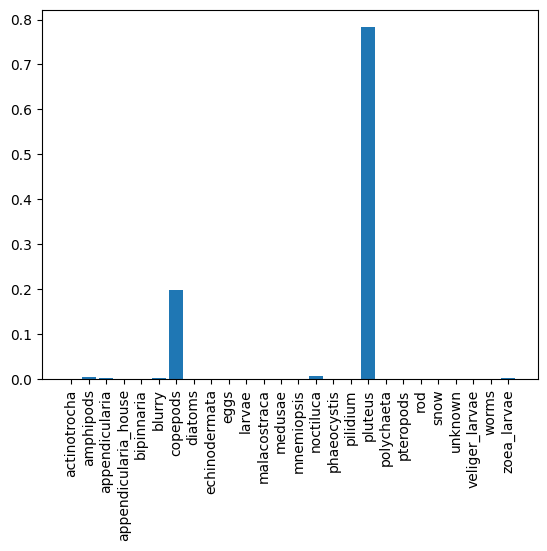

In [21]:
yhat = model.predict(resized)
plt.bar(class_names_map, yhat[0])
plt.xticks(rotation=90)
plt.show()

The last evaluation method was to take a certain amount of random images from each class, predict them, and plot the probabilities as a single line in a matrix where the lines are images of one class, and the columns represent the probabilities for each class.

If I can identify a column that is more yellow than any other column, it means the model is relatively sure about its prediction, and if the column is clear and pronounced, the model can consistenly guess the correct class. If, on the other hand, the matrix looks like a random nooise, that means the model has no idea what the correct class is.

This approach lets us see how the model behaves when trying to classify each and every class and it lets us have some insight about what could have gone wrong.

For example, many models struggle to find the difference between "rod" and "diatom", the class "unknown" often gets classified as another random class, and it seems particularly hard for models to classify "zoea_larvae"

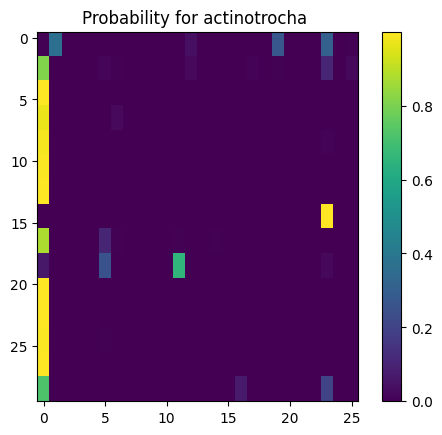

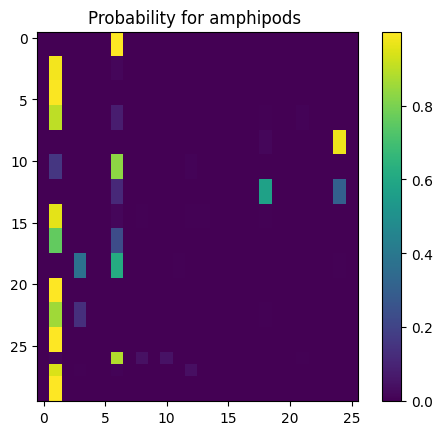

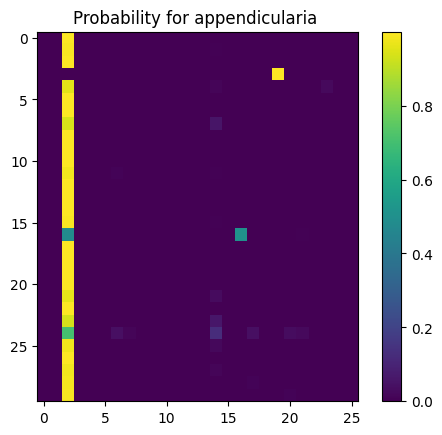

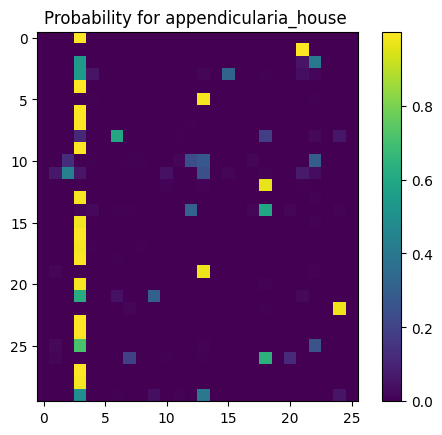

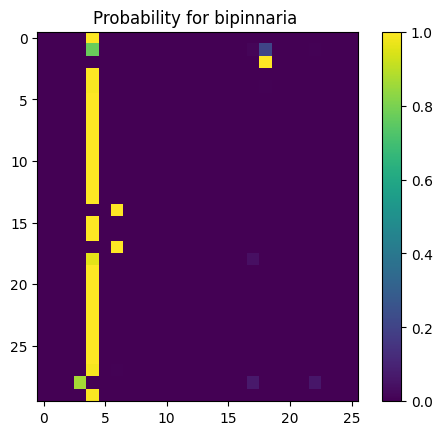

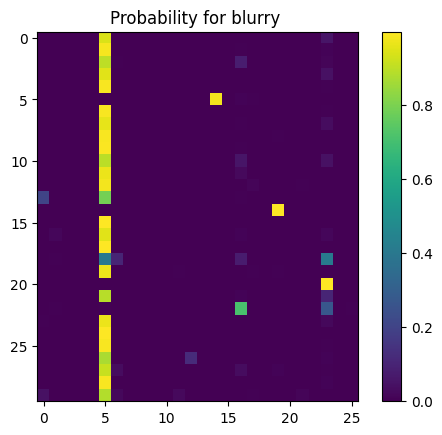

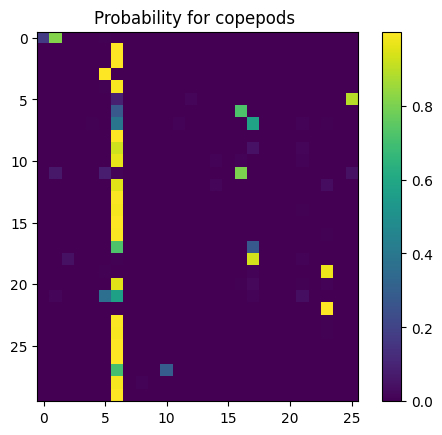

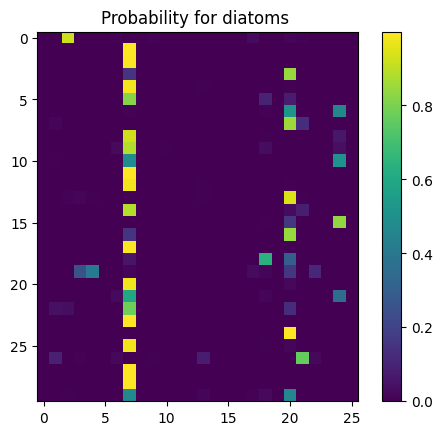

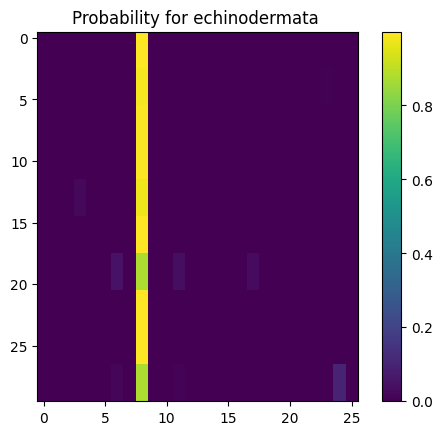

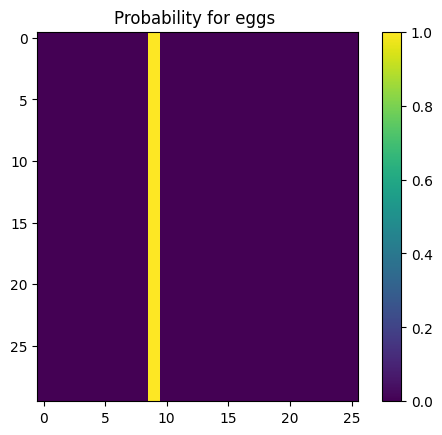

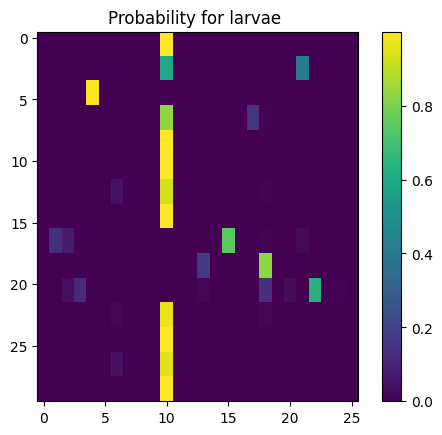

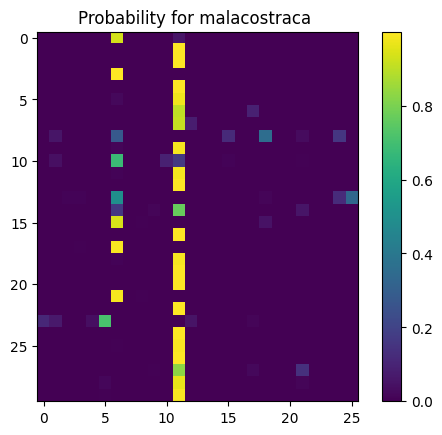

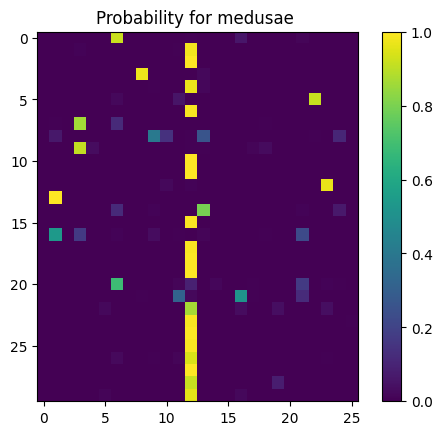

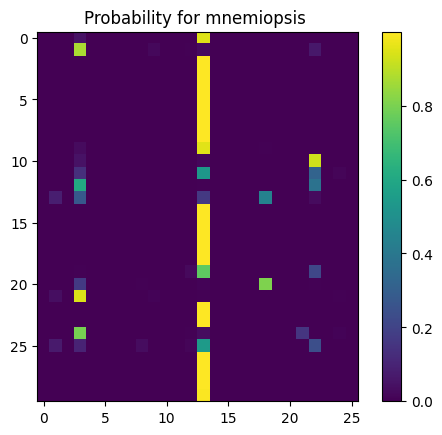

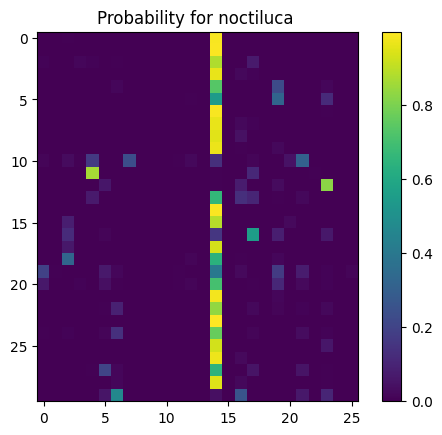

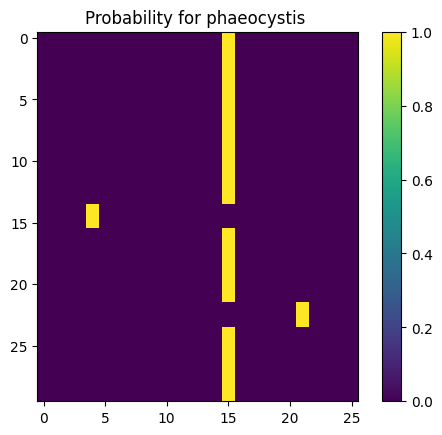

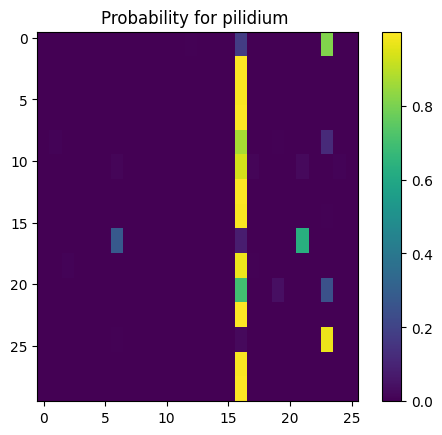

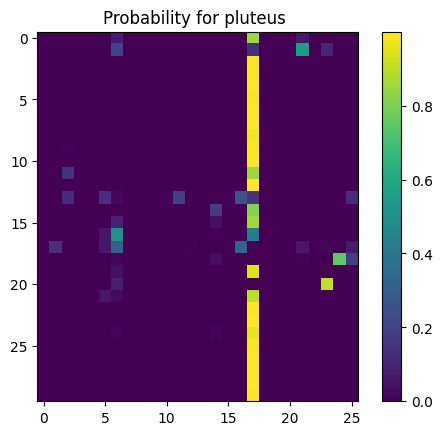

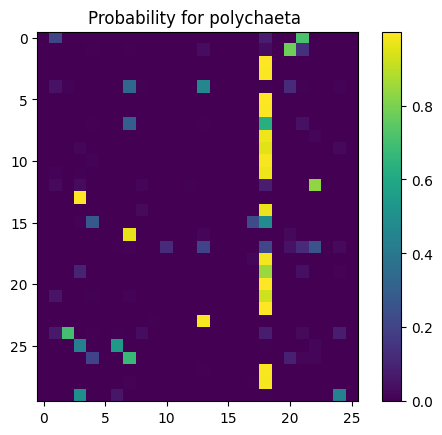

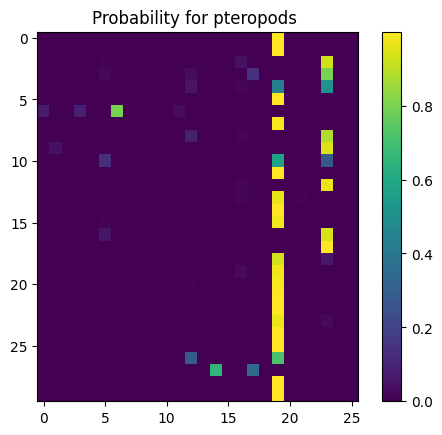

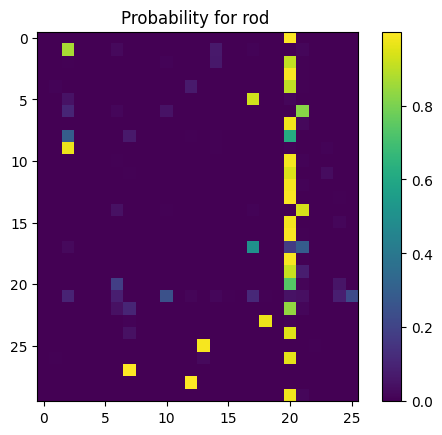

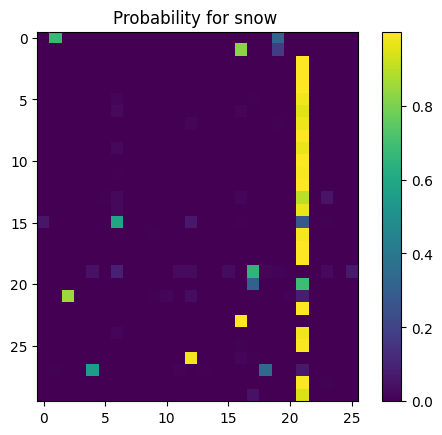

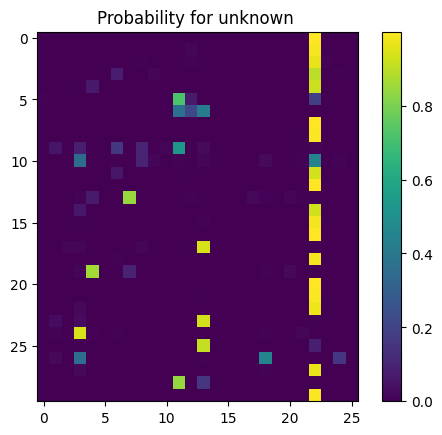

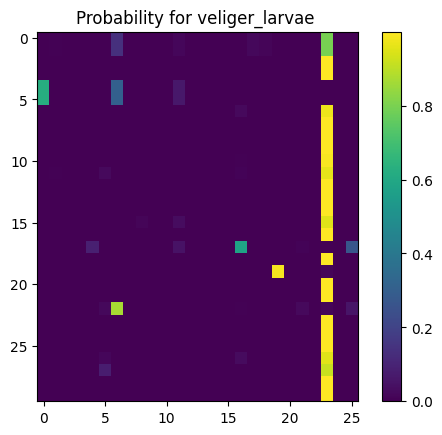

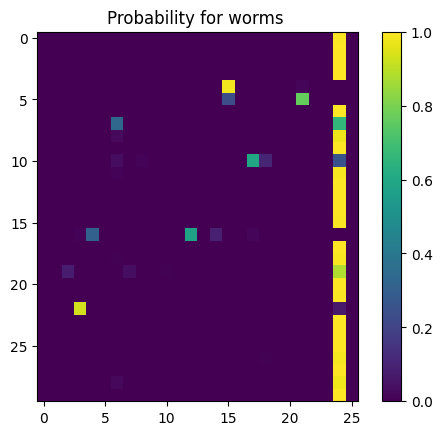

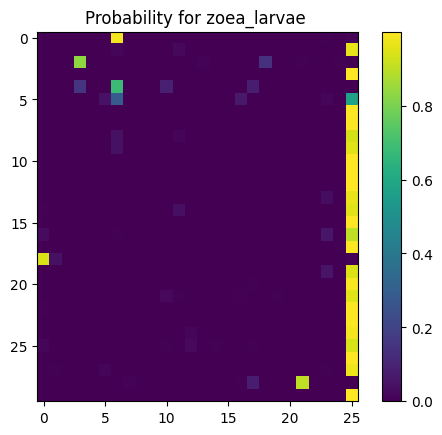

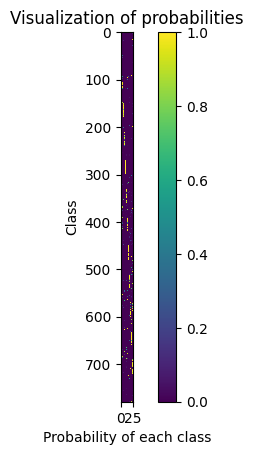

Correct: 597/780 Accuracy:  0.7653846153846153


In [25]:
testing_dir = "D:/ML_Dataset/subsets/equal_dist_300"
images_per_class = 30


probabilities = []
correct = 0
all_images = 0
for image_class in os.listdir(testing_dir):
    for i in range(images_per_class):
        files = os.listdir(f"{testing_dir}/{image_class}")
        count = len(files)
        file_name = files[i] if count > 1 else 1
        img = cv2.imread(f"{testing_dir}/{image_class}/{file_name}")
        resized = cv2.resize(img, model.input_shape[1:3])
        if model.input_shape[3] == 1:
            color = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        elif model.input_shape[3] == 3:
            color = resized # No change
        else:
            raise RuntimeError(f"No way of converting an image to {model.input_shape[3]} channels")
        resized = color / 255.0
        resized = np.expand_dims(resized, axis=0)
        yhat = model.predict(resized, verbose=3)
        predicted_class = np.argmax(yhat[0])

        if image_class == class_names_map[predicted_class]:
            correct += 1
        all_images += 1
        probabilities.append(yhat[0])

    plt.imshow(probabilities[-images_per_class:], cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.title(f'Probability for {image_class} ')
    plt.show()

matrix = probabilities


plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.xlabel('Probability of each class')
plt.ylabel('Class')
plt.title('Visualization of probabilities')
plt.show()

print("Correct:", f"{correct}/{all_images}", "Accuracy: ", correct / all_images)